In [2]:
import pandas as pd
df=pd.read_csv("C:\\Users\\DELL\\Downloads\\data_iris.csv")
df.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [7]:
features=['sepal_length','sepal_width','petal_length','petal_width']
for feature in features:
    Q1=df[feature].quantile(0.25)
    Q3=df[feature].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    df=df[(df[feature]>=lower_bound) & (df[feature]<=upper_bound)]

In [8]:
df.shape

(146, 5)

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

In [10]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['species']=encoder.fit_transform(df['species'])
x=df.drop(columns=['species']).values
y=df['species']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
model=GaussianNB()

In [12]:
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [13]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

Text(0.5, 1.0, 'Confusion Matrix')

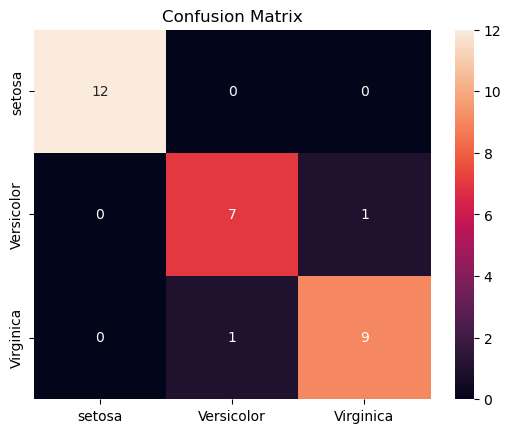

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
species_name=['setosa','Versicolor','Virginica']
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,color='blue',xticklabels=species_name,yticklabels=species_name)
plt.title('Confusion Matrix')

In [15]:
print(f"Accuracy score is: {accuracy_score(y_test,y_pred)}")
print(f"Recall score is: {recall_score(y_test,y_pred,average='macro')}")
print(f"precision score is :{precision_score(y_test,y_pred,average='macro')}")
print(f"f1 score is :{f1_score(y_test,y_pred,average='macro')}")

Accuracy score is: 0.9333333333333333
Recall score is: 0.9249999999999999
precision score is :0.9249999999999999
f1 score is :0.9249999999999999
